In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses, metrics
from sklearn.metrics import confusion_matrix

np.random.seed(0)
tf.random.set_seed(0)

In [44]:
X, y = load_wine(return_X_y=True) 
print("Dataset Shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Dataset Shape: (178, 13)
Number of classes: 3


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (124, 13)
Validation: (27, 13)
Test: (27, 13)


In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [47]:
y_train_cat = keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=3)
y_val_cat = keras.utils.to_categorical(y_val, num_classes=3)

In [48]:
model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax")
])


In [49]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3387 - loss: 1.0536 - val_accuracy: 0.5926 - val_loss: 0.8867
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6774 - loss: 0.8242 - val_accuracy: 0.7778 - val_loss: 0.6952
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8790 - loss: 0.6587 - val_accuracy: 0.8519 - val_loss: 0.5552
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9355 - loss: 0.5251 - val_accuracy: 0.9259 - val_loss: 0.4433
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9597 - loss: 0.4102 - val_accuracy: 0.9259 - val_loss: 0.3495
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9758 - loss: 0.3150 - val_accuracy: 0.9259 - val_loss: 0.2756
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9839 - loss: 0.2408 - val_accuracy: 0.9259 - val_loss: 0.2205
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9839 - loss: 0.1854 - val_accuracy: 0.9259 - val_loss: 0.1820
Epoch 9/100

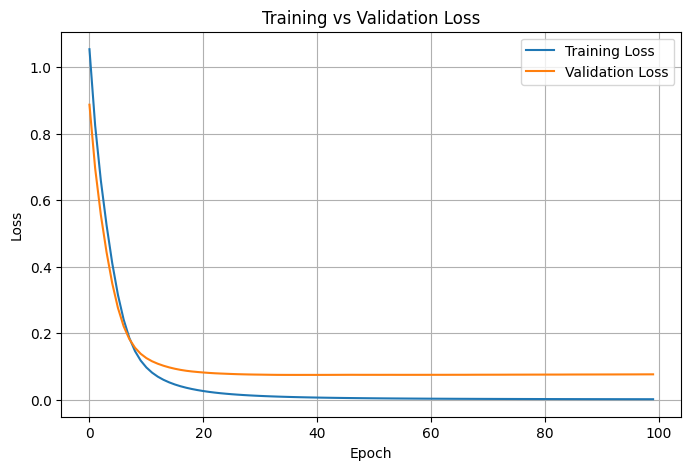

In [51]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()


In [52]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print("Test Accuracy:", test_accuracy)


Test Accuracy: 0.9629629850387573


In [ ]:
y_test_pred = np.argmax(model.predict(X_test_scaled), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.92      1.00      0.96        11
           2       1.00      0.86      0.92         7

    accuracy                           0.96        27
   macro avg       0.97      0.95      0.96        27
weighted avg       0.97      0.96      0.96        27



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


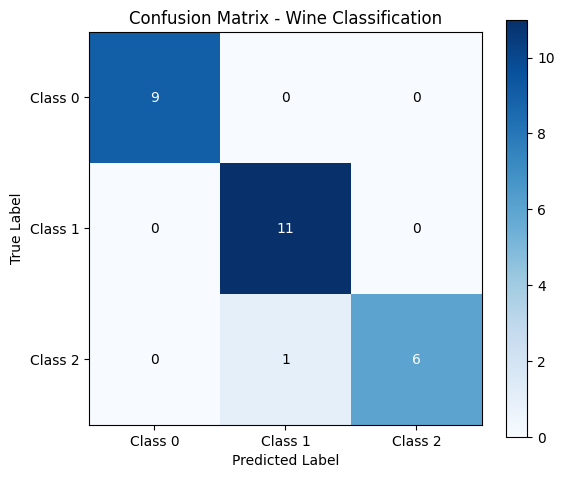

In [54]:
from sklearn.metrics import confusion_matrix

y_test_pred = np.argmax(model.predict(X_test_scaled), axis=1)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Wine Classification")
plt.colorbar()

class_names = ["Class 0", "Class 1", "Class 2"]
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()
